In [ ]:
import os, torch
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import PureWindowsPath
import matplotlib.pyplot as plt

/tmp/ipykernel_3666839/3997130925.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


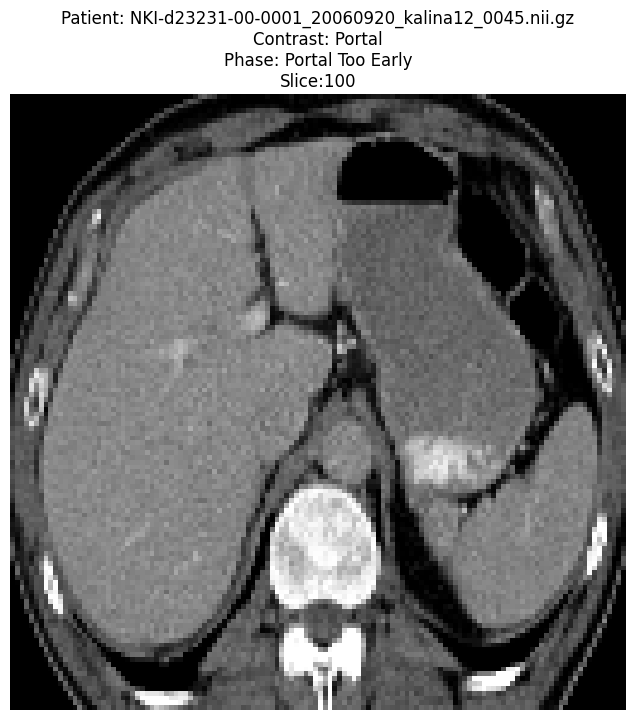

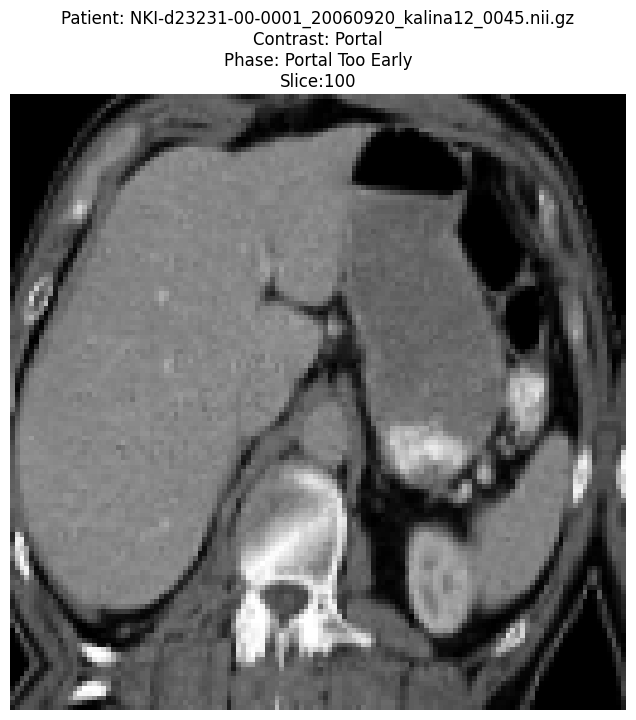

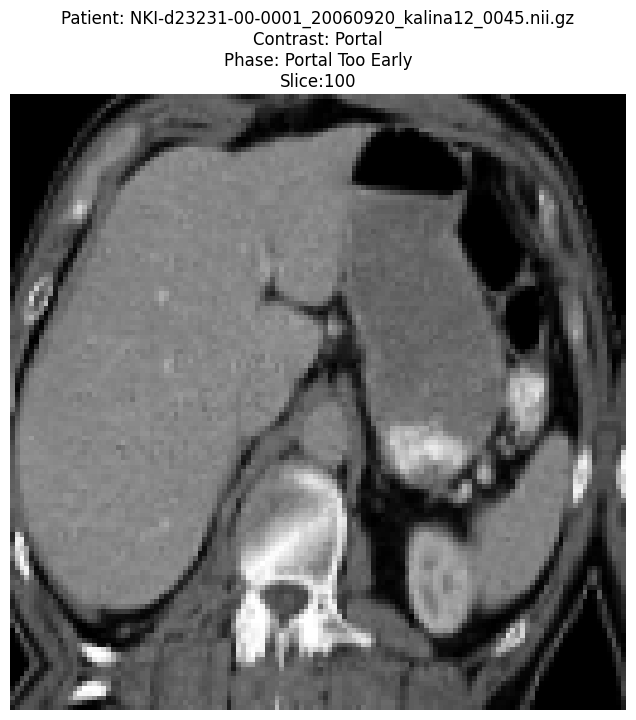

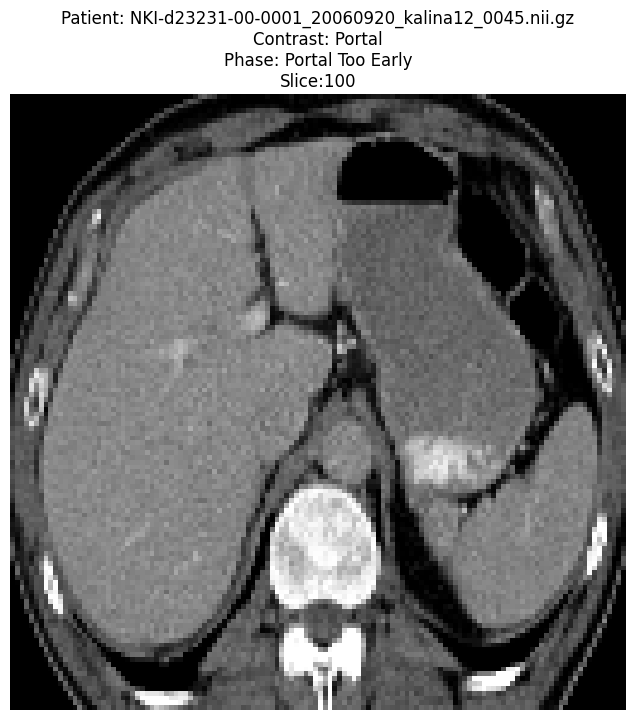

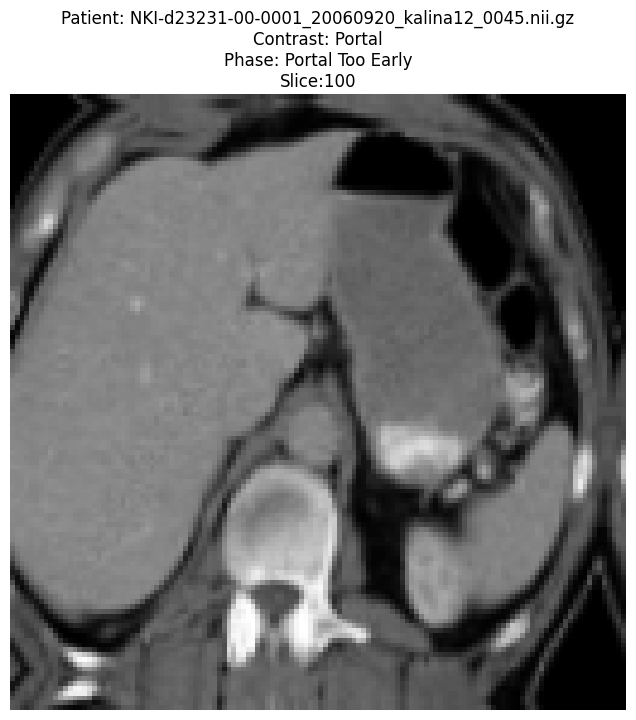

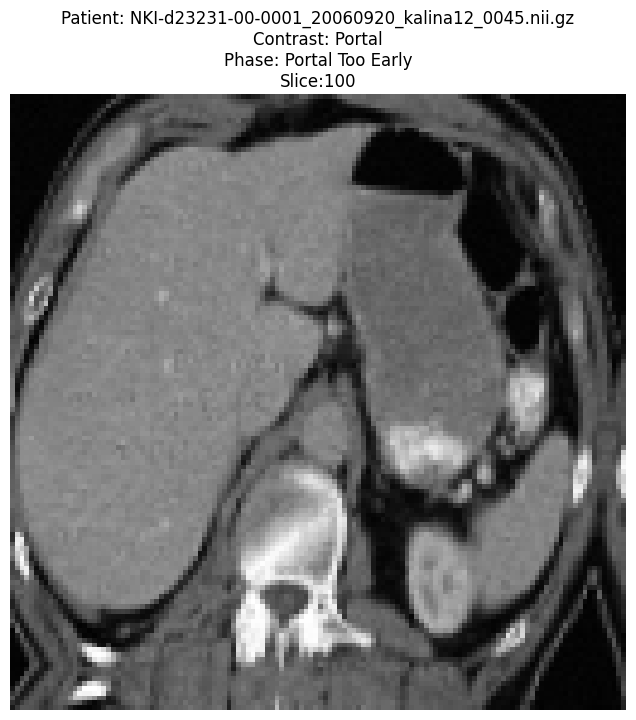

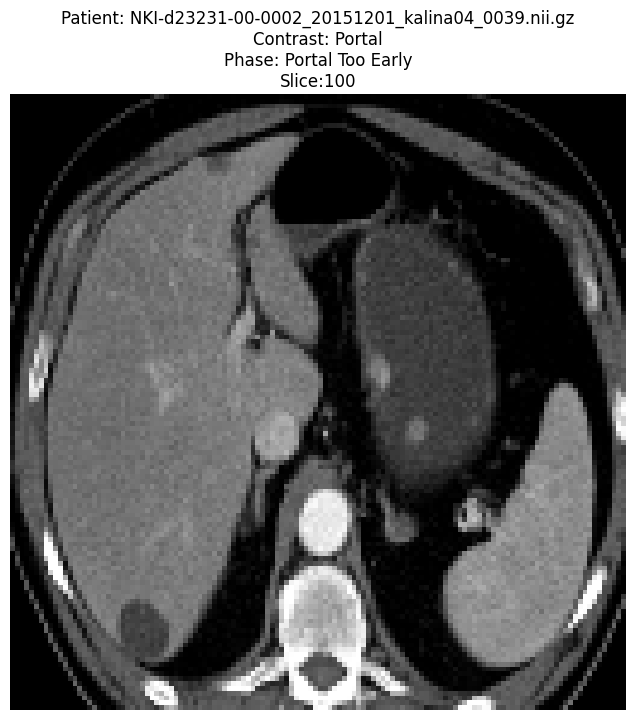

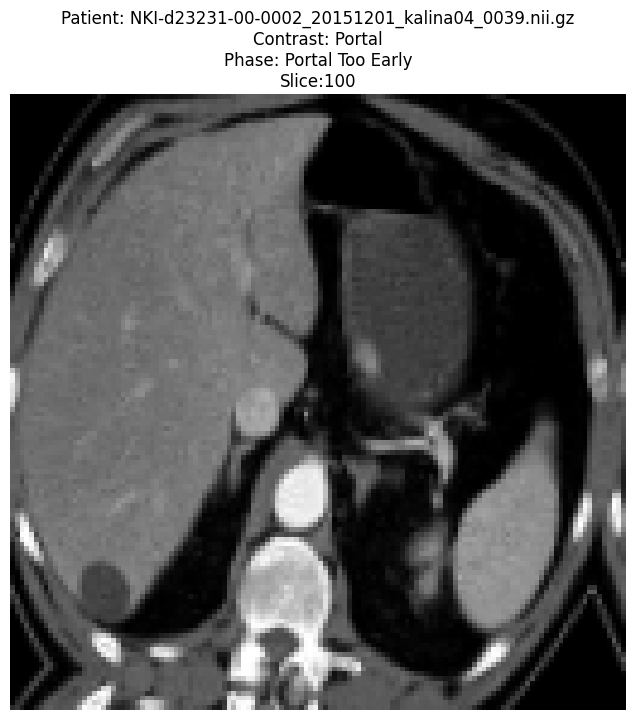

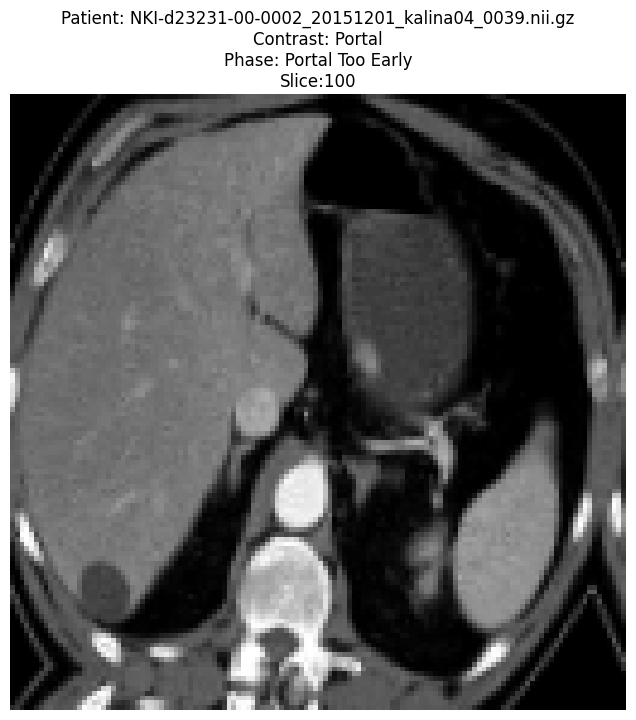

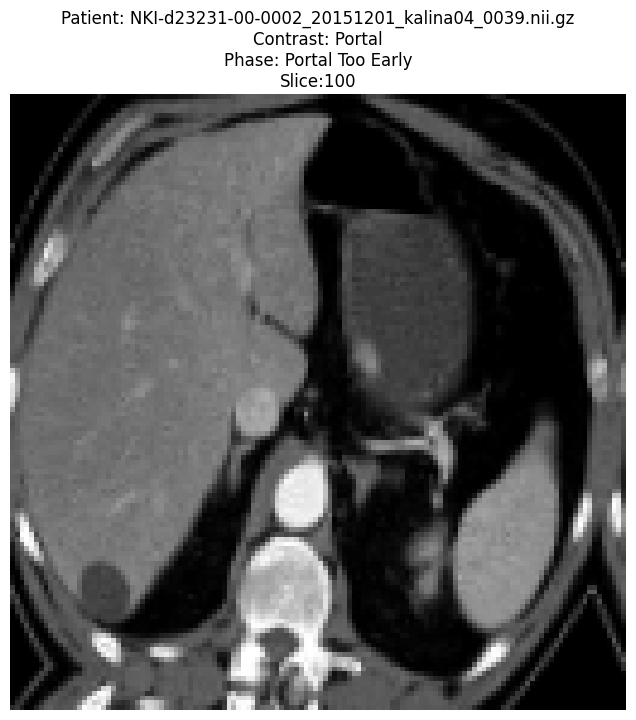

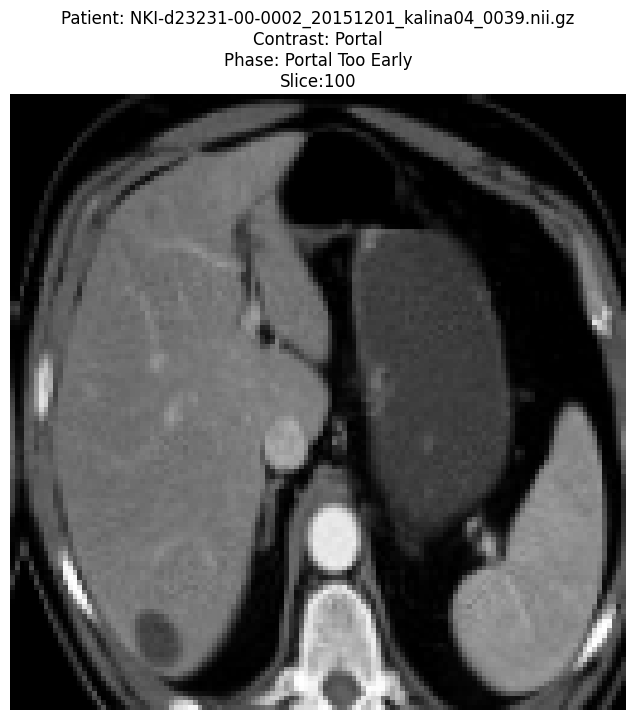

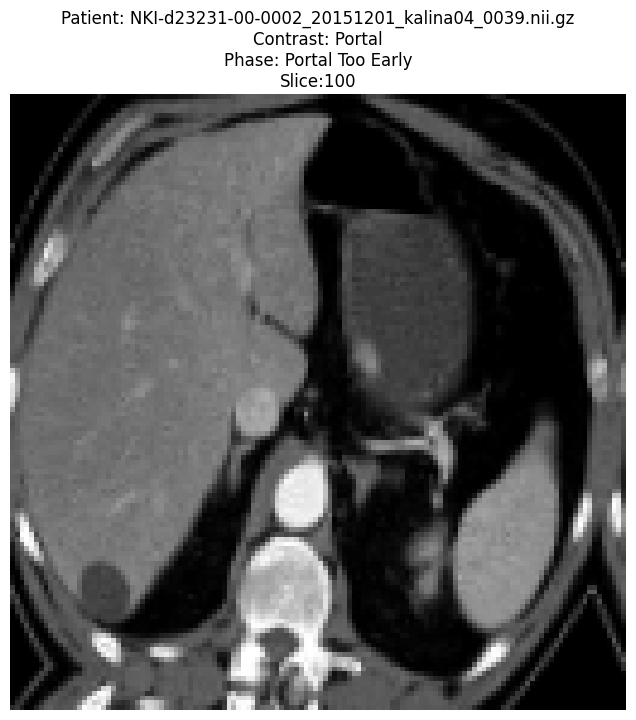

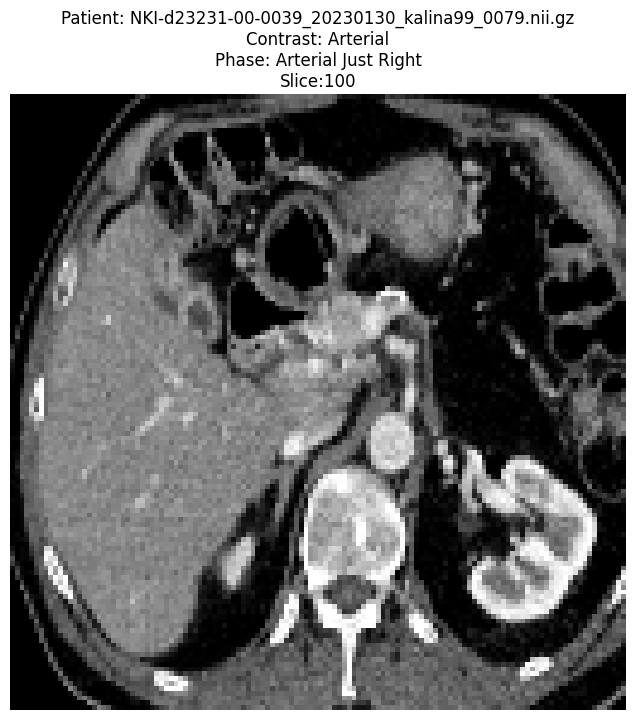

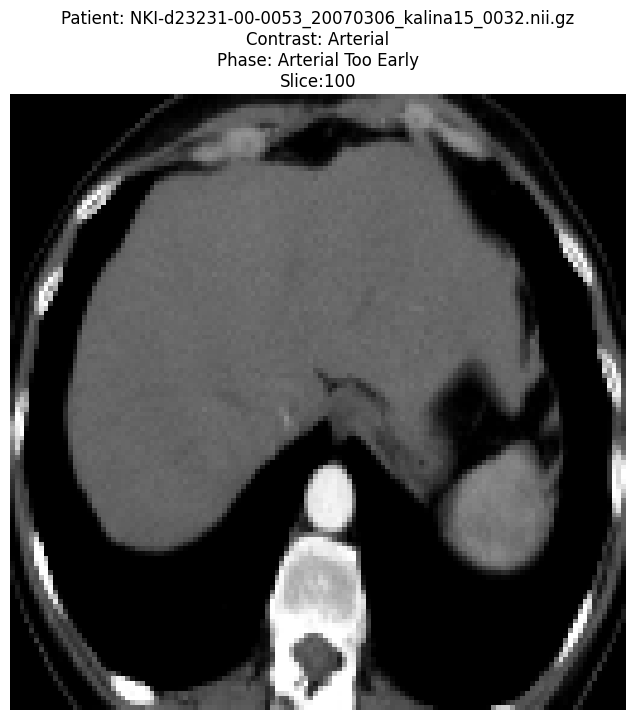

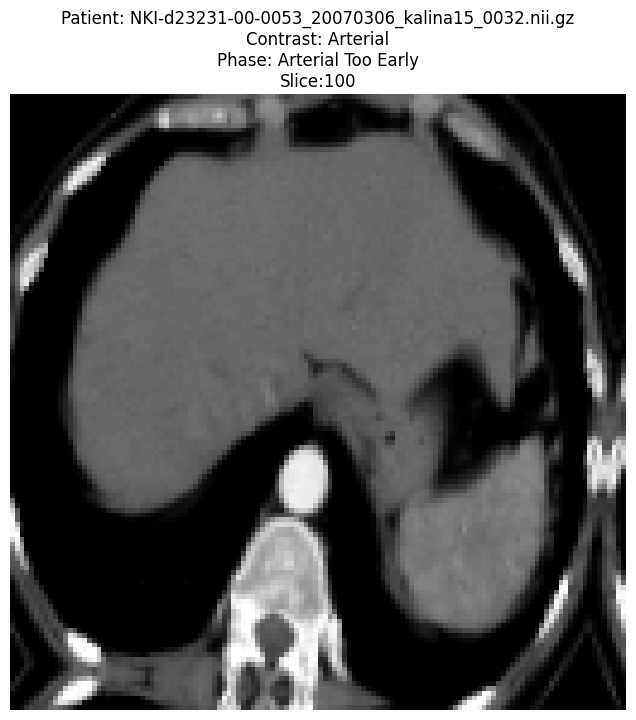

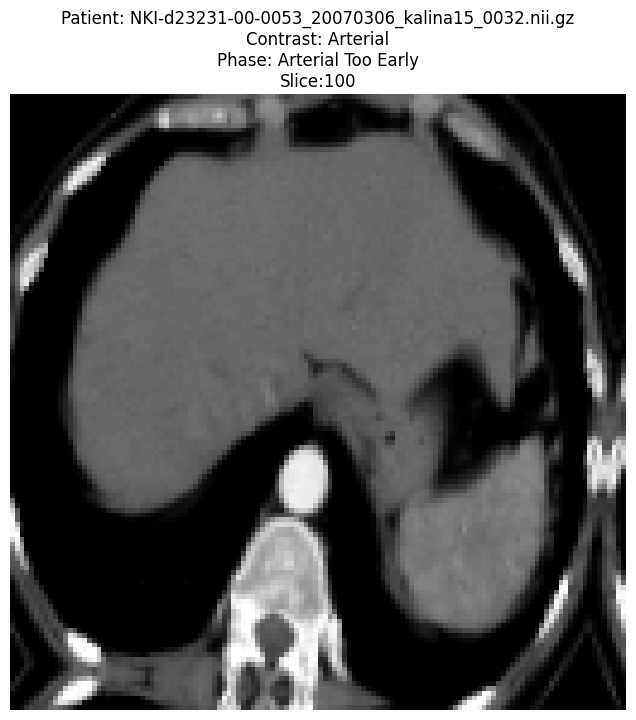

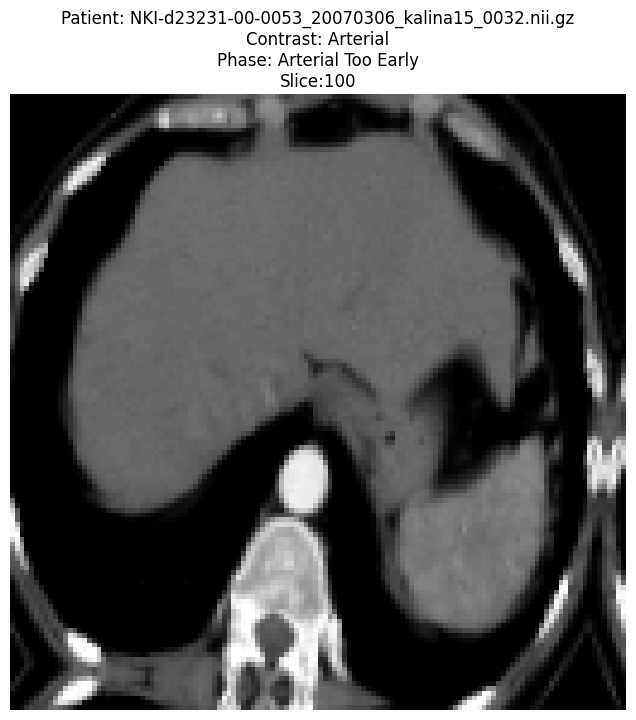

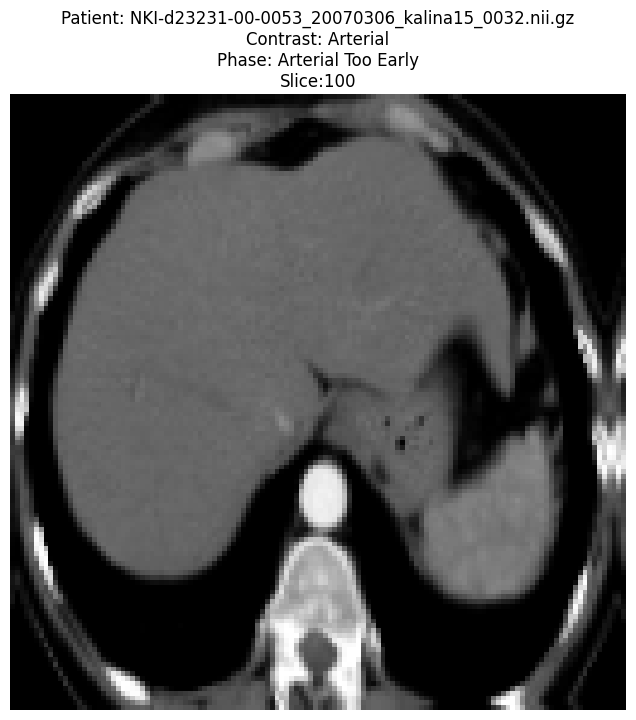

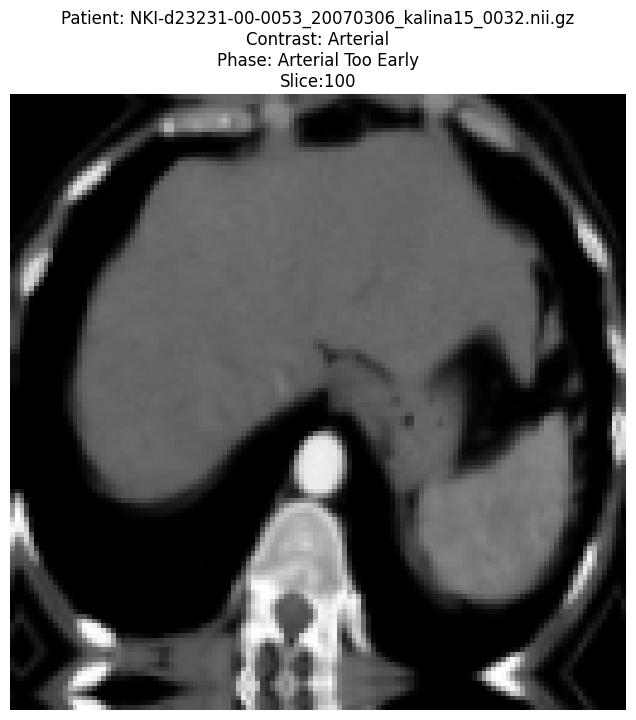

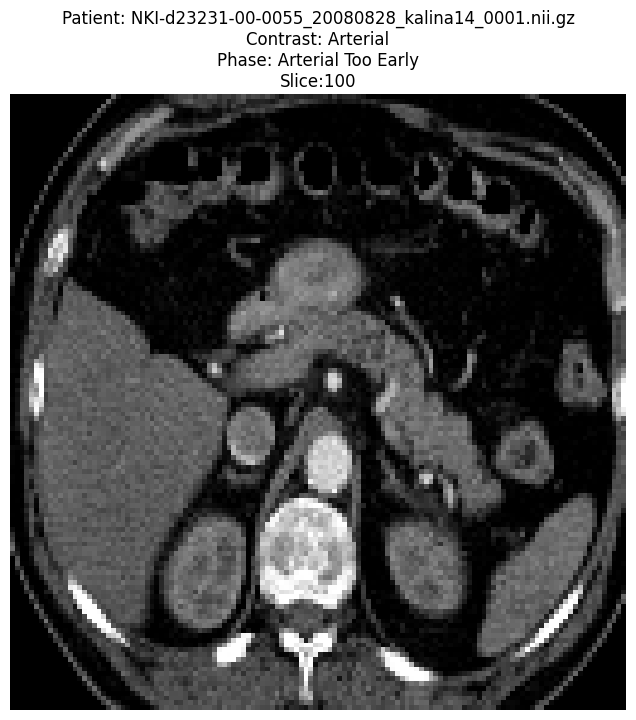

In [37]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_multipreprocessed/train"

def load_dataset(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".pt")])

    dataset = []
    i = 0
    while i < min(20, len(files)):
        f = files[i]
        data = torch.load(os.path.join(folder, f))
        dataset.append((data['patient_id'], data['key'], data["image"], data["contrast"], data['phase']))
        i += 1

    return dataset

data = load_dataset(folder)

slice = 100
for i in range(len(data)):
    image = data[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {data[i][1]}\nContrast: {data[i][3]}\nPhase: {data[i][4]}\nSlice:{slice}")
    plt.axis("off")

/tmp/ipykernel_3666839/3922809034.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


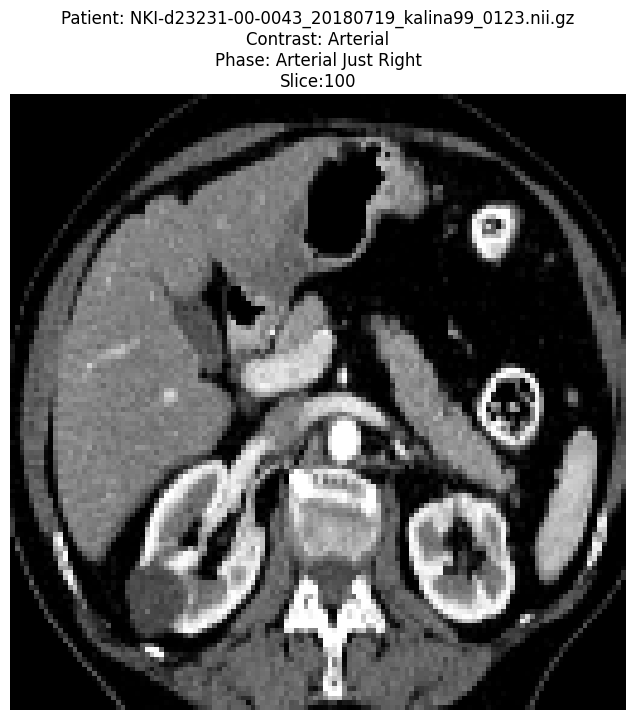

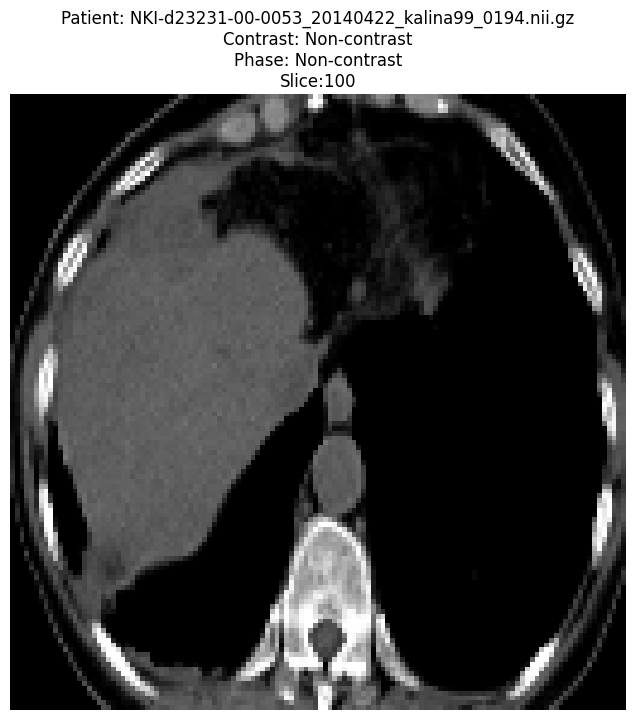

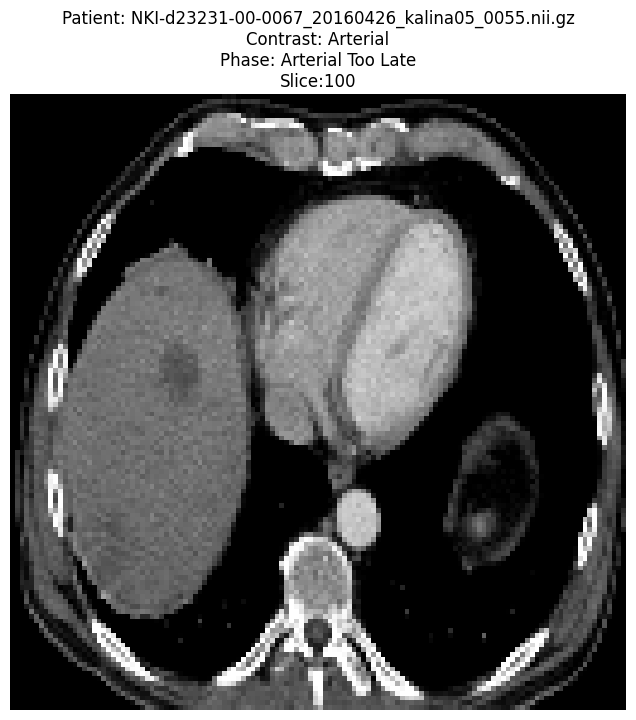

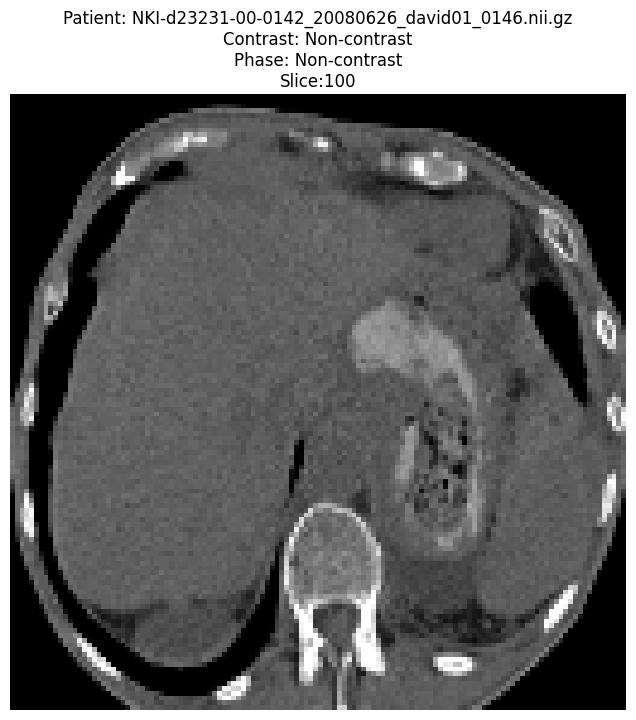

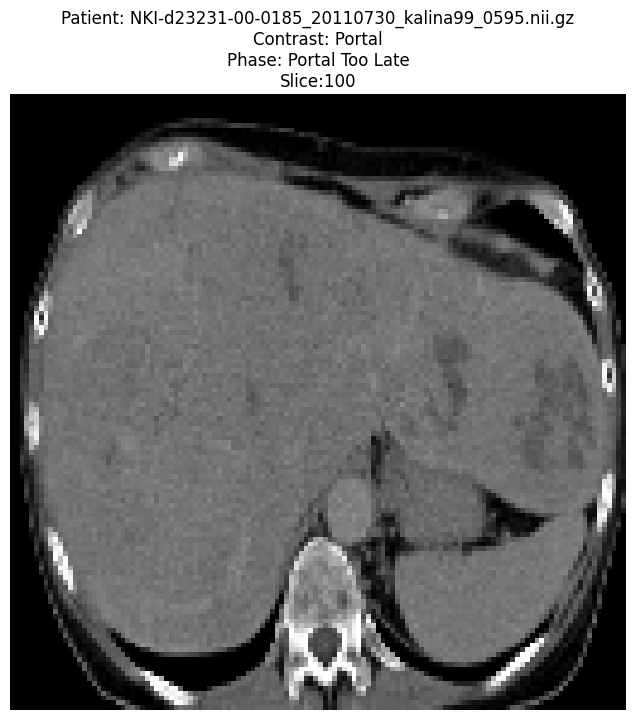

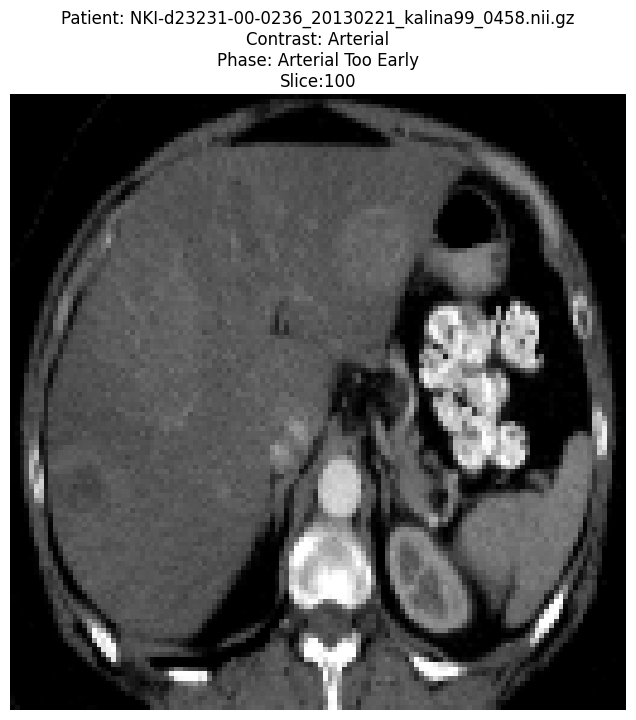

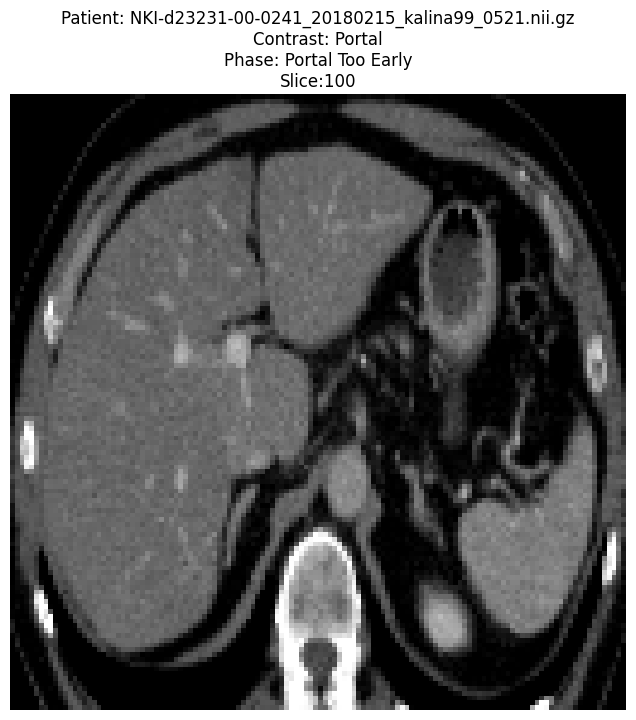

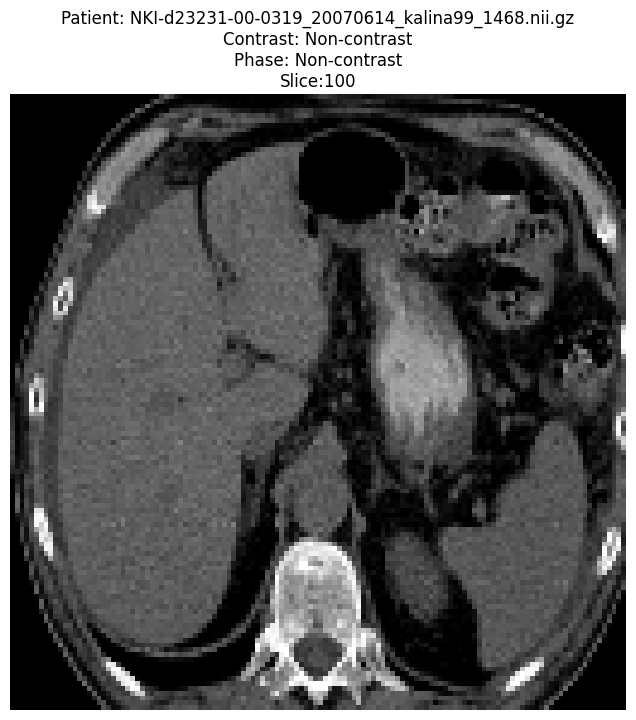

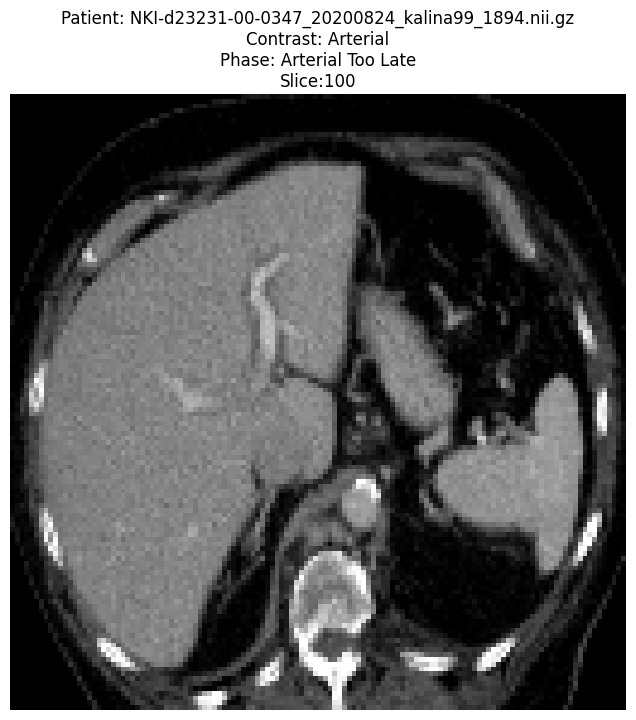

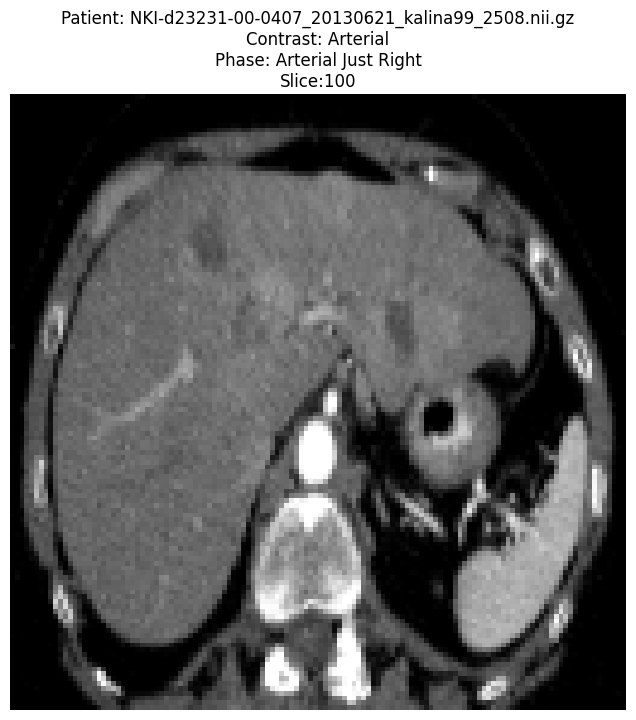

In [38]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_multipreprocessed/val"

def load_dataset(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".pt")])

    dataset = []
    i = 0
    while i < min(10, len(files)):
        f = files[i]
        data = torch.load(os.path.join(folder, f))
        dataset.append((data['patient_id'], data['key'], data["image"], data["contrast"], data['phase']))
        i += 1

    return dataset

data = load_dataset(folder)
slice = 100
for i in range(len(data)):
    image = data[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {data[i][1]}\nContrast: {data[i][3]}\nPhase: {data[i][4]}\nSlice:{slice}")
    plt.axis("off")

In [16]:
def contrast_timing(dataset):
    dataset["contrast_timing"] = dataset["contrast"]
    mask = dataset["contrast"] != "Non-contrast"
    dataset.loc[mask, "contrast_timing"] = (dataset.loc[mask, "contrast"] + " " + dataset.loc[mask, "phase_timing"].astype(str))
    dataset.loc[mask, "contrast_timing"] = dataset.loc[mask, "contrast_timing"].str.strip()
    dataset.loc[dataset["contrast"] == "Non-contrast", "contrast_timing"] = "Non-contrast"   

    return dataset


def files_load(data_dir, sample=None):
    dataset = pd.read_csv(data_dir)

    dataset['server_folder'] = dataset.exist_on_server.apply(
        lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"
        if pd.notna(x)
        else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server"
    )

    dataset = dataset[
        (dataset.contrast.isin(['Arterial', "Portal", "Non-contrast"])) &
        (dataset.is_liver_imaged.isin(["Yes", "Partially"])) &
        (dataset.phase_timing != '0.0')
    ]

    dataset.loc[dataset["contrast"] == "Non-contrast", "phase_timing"] = None               # ensure NC cases have None phase_timing for safe concatenation

    dataset = contrast_timing(dataset)       # ensure NC cases have None contrast_timing for safe concatenation

    # ---------------- SAMPLE ----------------
    if sample is not None:
        dataset = (dataset.groupby('contrast_timing', dropna=False, group_keys=False)
                   .apply(lambda x: x.sample(n=min(len(x), sample), random_state=42))
                   .reset_index(drop=True))
        
        dataset = contrast_timing(dataset)   # re-apply contrast_timing after sampling to ensure consistency
        dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle rows
        


    # ---------------- FILE PATHS ----------------
    files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in dataset.iterrows()]

    organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]

    contrast = dataset["contrast"].tolist()
    phase = dataset["contrast_timing"].tolist()
    keys = dataset['MatchKey'].tolist()
    patient_id = dataset['SubjectKeyRadiology'].tolist()

    return patient_id, keys, files, organ_files, contrast, phase

In [17]:
data_dir = "/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv"
patient_ids,keys, image_files, organ_files, contrast, phase = files_load(data_dir, sample = 100)

In [ ]:
phase

['Portal Too Early',
 'Non-contrast',
 'Arterial Too Late',
 'Arterial Just Right',
 'Non-contrast',
 'Arterial Just Right',
 'Portal Too Late',
 'Non-contrast',
 'Arterial Just Right',
 'Arterial Too Late',
 'Portal Too Late',
 'Arterial Too Early',
 'Arterial Too Late',
 'Arterial Too Early',
 'Non-contrast',
 'Arterial Too Late',
 'Portal Too Early',
 'Non-contrast',
 'Arterial Too Late',
 'Arterial Just Right',
 'Arterial Too Late',
 'Arterial Too Early',
 'Arterial Too Late',
 'Portal Just Right',
 'Portal Just Right',
 'Portal Too Late',
 'Arterial Too Early',
 'Arterial Too Late',
 'Portal Too Early',
 'Portal Too Early',
 'Non-contrast',
 'Arterial Just Right',
 'Portal Too Early',
 'Arterial Too Early',
 'Arterial Too Early',
 'Arterial Just Right',
 'Arterial Just Right',
 'Arterial Too Early',
 'Arterial Too Early',
 'Portal Just Right',
 'Arterial Just Right',
 'Non-contrast',
 'Arterial Just Right',
 'Non-contrast',
 'Arterial Too Early',
 'Portal Just Right',
 'Arterial T

In [19]:
from sklearn.model_selection import GroupShuffleSplit

def group_train_test_split(indices, test_size=0.2, groups=None):
    """
    Splits indices into train/test without splitting the same group across sets.
    
    Args:
        indices: array-like of indices to split (e.g., np.arange(len(images)))
        test_size: fraction of data to use as test
        groups: array-like of same length as indices indicating group membership
    
    Returns:
        train_idx, test_idx: arrays of indices
    """
    splitter = GroupShuffleSplit(test_size=test_size, n_splits=1, random_state=42)
    train_idx, test_idx = next(splitter.split(indices, groups=groups))

    return train_idx, test_idx

def data_split(image_files, patient_ids):
    all_indices = np.arange(len(image_files))

    # First split: train+val vs test
    temp_idx, test_idx = group_train_test_split(all_indices, test_size=0.2, groups=patient_ids)

    # Second split: train vs val
    train_idx, val_idx = group_train_test_split(temp_idx, test_size=0.2, groups=np.array(patient_ids)[temp_idx])

    return train_idx, val_idx, test_idx

In [20]:
train_idx, val_idx, test_idx = data_split(image_files=image_files, patient_ids=patient_ids)


In [21]:
print(len(train_idx), len(val_idx), len(test_idx))
print("Total:", len(image_files))

426 91 141
Total: 658
